# Sales Forecasting Using Machine Learning

## Machine Learning Time Series Project

This project uses Machine Learning algorithms to analyze historical sales data and predict future sales.

The project includes data analysis, feature engineering, multiple machine learning models, model comparison, and future sales forecasting.

## Project Workflow

1. Data Loading and Understanding
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Time-Based Train-Test Split
6. Model Training
7. Model Evaluation and Comparison
8. Future Sales Forecasting
9. Feature Importance Analysis
10. Business Insights
11. Saving Project Outputs
12. conclusion


# 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


# 2. Create and Load Sales Dataset

In [2]:
# Create reproducible sample sales dataset

np.random.seed(42)

dates = pd.date_range(
    start="2022-01-01",
    end="2024-12-31",
    freq="D"
)

sales = (
    500
    + np.arange(len(dates)) * 0.05
    + 100 * np.sin(2 * np.pi * dates.dayofyear / 365.25)
    + np.random.normal(0, 30, len(dates))
)

df = pd.DataFrame({
    "Date": dates,
    "Sales": np.round(sales, 2)
})

df.head()

,Date,Sales
0,2022-01-01,516.62
1,2022-01-02,499.34
2,2022-01-03,524.69
3,2022-01-04,552.72
4,2022-01-05,501.77


# 3. Dataset Understanding

## 3.1 Basic Dataset Information

In [3]:
print("Dataset Shape:", df.shape)
print("\nDataset Information:")
df.info()

Dataset Shape: (1096, 2)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1096 non-null   datetime64[ns]
 1   Sales   1096 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 17.3 KB


In [4]:
# Display first 5 rows
display(df.head())

# Display last 5 rows
display(df.tail())

# Dataset dimensions
print("Dataset Shape:", df.shape)

# Check column names
print("\nColumns:")
print(df.columns)

# Data types and null values
print("\nDataset Info:")
df.info()

,Date,Sales
0,2022-01-01,516.62
1,2022-01-02,499.34
2,2022-01-03,524.69
3,2022-01-04,552.72
4,2022-01-05,501.77


,Date,Sales
1091,2024-12-27,547.85
1092,2024-12-28,572.56
1093,2024-12-29,554.06
1094,2024-12-30,576.25
1095,2024-12-31,553.62


Dataset Shape: (1096, 2)

Columns:
Index(['Date', 'Sales'], dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1096 non-null   datetime64[ns]
 1   Sales   1096 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 17.3 KB


## 3.2 Check Missing Values

In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Date     0
Sales    0
dtype: int64


## 3.3 Check Duplicate Rows

In [6]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## 3.4 Statistical Summary

In [7]:
df.describe()

,Date,Sales
count,1096,1096.000000
mean,2023-07-02 12:00:00,528.361451
min,2022-01-01 00:00:00,317.630000
25%,2022-10-01 18:00:00,469.125000
50%,2023-07-02 12:00:00,525.155000
75%,2024-04-01 06:00:00,590.097500
max,2024-12-31 00:00:00,710.020000
std,NaN,74.216488


# 4. Data Cleaning and Preparation

## 4.1 Convert and Prepare Date Column

In [8]:
df["Date"] = pd.to_datetime(df["Date"])

# Sort data by date
df = df.sort_values("Date").reset_index(drop=True)

print("Date column converted successfully!")
print("Date range:", df["Date"].min(), "to", df["Date"].max())

Date column converted successfully!
Date range: 2022-01-01 00:00:00 to 2024-12-31 00:00:00


## 4.2 Remove Duplicates and Missing Values

In [9]:
# Remove duplicate rows
df = df.drop_duplicates()

# Drop missing values
df = df.dropna()

print("Final Dataset Shape:", df.shape)

Final Dataset Shape: (1096, 2)


# 5. Exploratory Data Analysis (EDA)

## 5.1 Daily Sales Trend

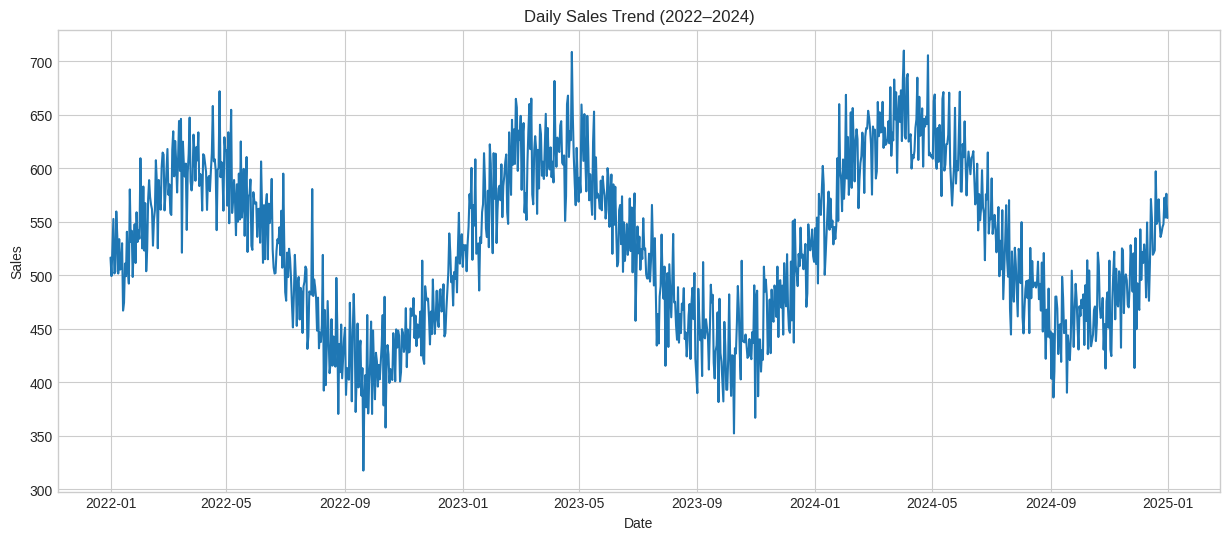

In [10]:
plt.figure(figsize=(15, 6))

plt.plot(df["Date"], df["Sales"])

plt.title("Daily Sales Trend (2022–2024)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

## 5.2 Monthly Sales Comparison

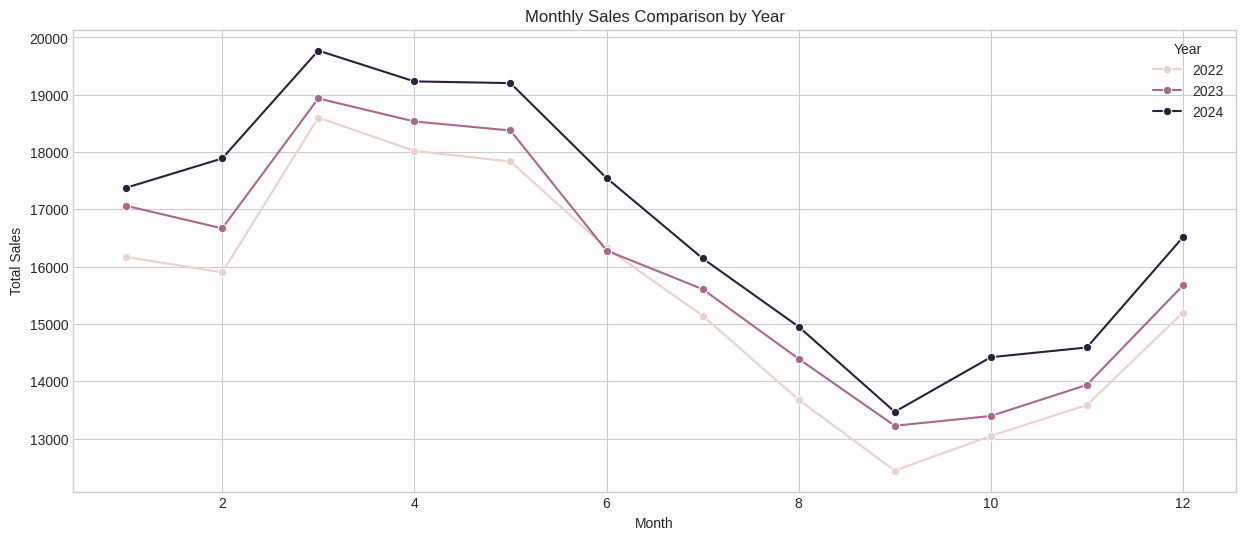

In [11]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()

monthly_sales = (
    df.groupby(["Year", "Month"])["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(15, 6))

sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Sales",
    hue="Year",
    marker="o"
)

plt.title("Monthly Sales Comparison by Year")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

## 5.3 Sales Distribution

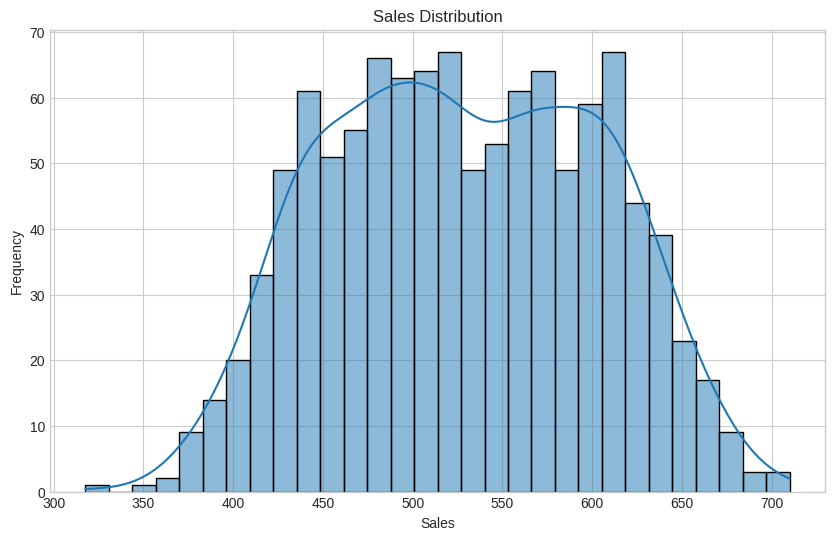

In [12]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Sales"],
    bins=30,
    kde=True
)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

## 5.4 Monthly Average Sales

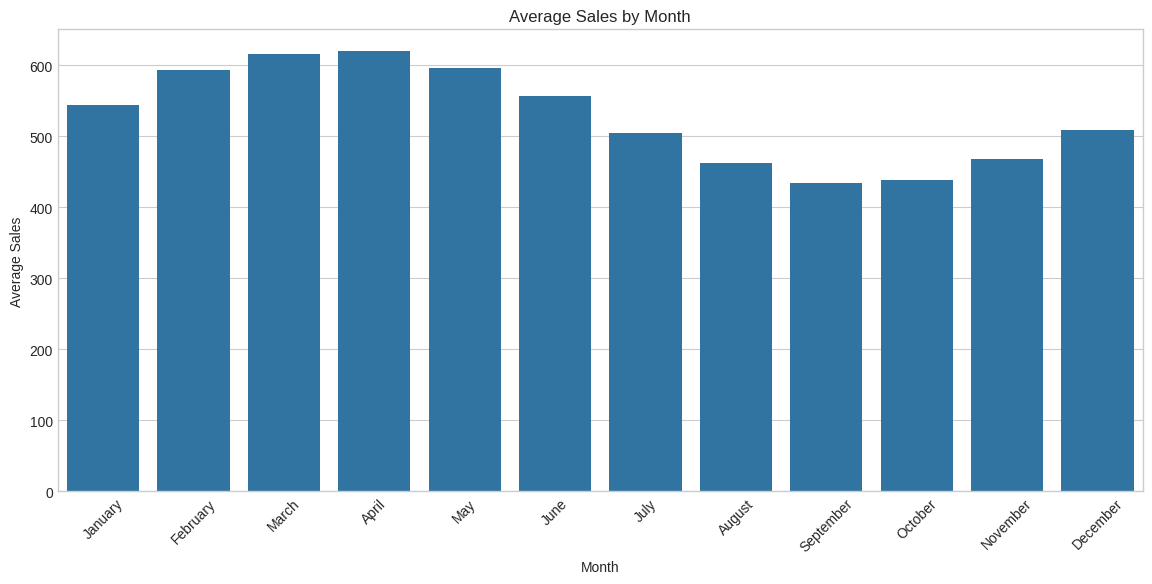

In [13]:
monthly_avg_sales = (
    df.groupby("Month_Name")["Sales"]
    .mean()
    .reindex([
        "January", "February", "March", "April",
        "May", "June", "July", "August",
        "September", "October", "November", "December"
    ])
)

plt.figure(figsize=(14, 6))

sns.barplot(
    x=monthly_avg_sales.index,
    y=monthly_avg_sales.values
)

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.xticks(rotation=45)
plt.show()

# 6. Feature Engineering

## 6.1 Create Date-Based Features

In [14]:
# Date-based features

df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
df["Quarter"] = df["Date"].dt.quarter

df.head()

,Date,Sales,Year,Month,Month_Name,Day,DayOfWeek,WeekOfYear,Quarter
0,2022-01-01,516.62,2022,1,January,1,5,52,1
1,2022-01-02,499.34,2022,1,January,2,6,52,1
2,2022-01-03,524.69,2022,1,January,3,0,1,1
3,2022-01-04,552.72,2022,1,January,4,1,1,1
4,2022-01-05,501.77,2022,1,January,5,2,1,1


## 6.2 Create Lag Features

In [15]:
# Lag features

df["Lag_1"] = df["Sales"].shift(1)
df["Lag_7"] = df["Sales"].shift(7)
df["Lag_30"] = df["Sales"].shift(30)

df.head(10)

,Date,Sales,Year,Month,Month_Name,Day,DayOfWeek,WeekOfYear,Quarter,Lag_1,Lag_7,Lag_30
0,2022-01-01,516.62,2022,1,January,1,5,52,1,NaN,NaN,NaN
1,2022-01-02,499.34,2022,1,January,2,6,52,1,516.62,NaN,NaN
2,2022-01-03,524.69,2022,1,January,3,0,1,1,499.34,NaN,NaN
3,2022-01-04,552.72,2022,1,January,4,1,1,1,524.69,NaN,NaN
4,2022-01-05,501.77,2022,1,January,5,2,1,1,552.72,NaN,NaN
5,2022-01-06,503.53,2022,1,January,6,3,1,1,501.77,NaN,NaN
6,2022-01-07,559.69,2022,1,January,7,4,1,1,503.53,NaN,NaN
7,2022-01-08,537.09,2022,1,January,8,5,1,1,559.69,516.62,NaN
8,2022-01-09,501.74,2022,1,January,9,6,1,1,537.09,499.34,NaN
9,2022-01-10,533.84,2022,1,January,10,0,2,1,501.74,524.69,NaN


## 6.3 Create Rolling Average Features

In [16]:
# Rolling average features

df["Rolling_Mean_7"] = df["Sales"].shift(1).rolling(window=7).mean()

df["Rolling_Mean_30"] = df["Sales"].shift(1).rolling(window=30).mean()

df.head(35)

,Date,Sales,Year,Month,Month_Name,Day,DayOfWeek,WeekOfYear,Quarter,Lag_1,Lag_7,Lag_30,Rolling_Mean_7,Rolling_Mean_30
0,2022-01-01,516.62,2022,1,January,1,5,52,1,NaN,NaN,NaN,NaN,NaN
1,2022-01-02,499.34,2022,1,January,2,6,52,1,516.62,NaN,NaN,NaN,NaN
2,2022-01-03,524.69,2022,1,January,3,0,1,1,499.34,NaN,NaN,NaN,NaN
3,2022-01-04,552.72,2022,1,January,4,1,1,1,524.69,NaN,NaN,NaN,NaN
4,2022-01-05,501.77,2022,1,January,5,2,1,1,552.72,NaN,NaN,NaN,NaN
5,2022-01-06,503.53,2022,1,January,6,3,1,1,501.77,NaN,NaN,NaN,NaN
6,2022-01-07,559.69,2022,1,January,7,4,1,1,503.53,NaN,NaN,NaN,NaN
7,2022-01-08,537.09,2022,1,January,8,5,1,1,559.69,516.62,NaN,522.622857,NaN
8,2022-01-09,501.74,2022,1,January,9,6,1,1,537.09,499.34,NaN,525.547143,NaN
9,2022-01-10,533.84,2022,1,January,10,0,2,1,501.74,524.69,NaN,525.890000,NaN


## 6.4 Prepare Final Dataset for Modeling

In [17]:
# Remove rows created with NaN values from lag features

df_model = df.dropna().copy()

print("Original Dataset Shape:", df.shape)
print("Model Dataset Shape:", df_model.shape)

Original Dataset Shape: (1096, 14)
Model Dataset Shape: (1066, 14)


In [18]:
print(df_model.columns.tolist())

['Date', 'Sales', 'Year', 'Month', 'Month_Name', 'Day', 'DayOfWeek', 'WeekOfYear', 'Quarter', 'Lag_1', 'Lag_7', 'Lag_30', 'Rolling_Mean_7', 'Rolling_Mean_30']


# 7. Prepare Data for Machine Learning

## 7.1 Define Features and Target Variable

In [19]:
# Features used for sales prediction
features = [
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",
    "Lag_1",
    "Lag_7",
    "Lag_30",
    "Rolling_Mean_7",
    "Rolling_Mean_30"
]

# Input features
X = df_model[features]

# Target variable
y = df_model["Sales"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1066, 11)
y Shape: (1066,)


## 7.2 Time-Based Train-Test Split

In [20]:
# 80% training data
train_size = int(len(df_model) * 0.80)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (852, 11)
Testing data: (214, 11)


## 7.3 Verify Training and Testing Periods

In [21]:
train_dates = df_model["Date"].iloc[:train_size]
test_dates = df_model["Date"].iloc[train_size:]

print("Training Period:")
print(train_dates.min(), "to", train_dates.max())

print("\nTesting Period:")
print(test_dates.min(), "to", test_dates.max())

Training Period:
2022-01-31 00:00:00 to 2024-05-31 00:00:00

Testing Period:
2024-06-01 00:00:00 to 2024-12-31 00:00:00


## 7.4 Visualize Train-Test Split

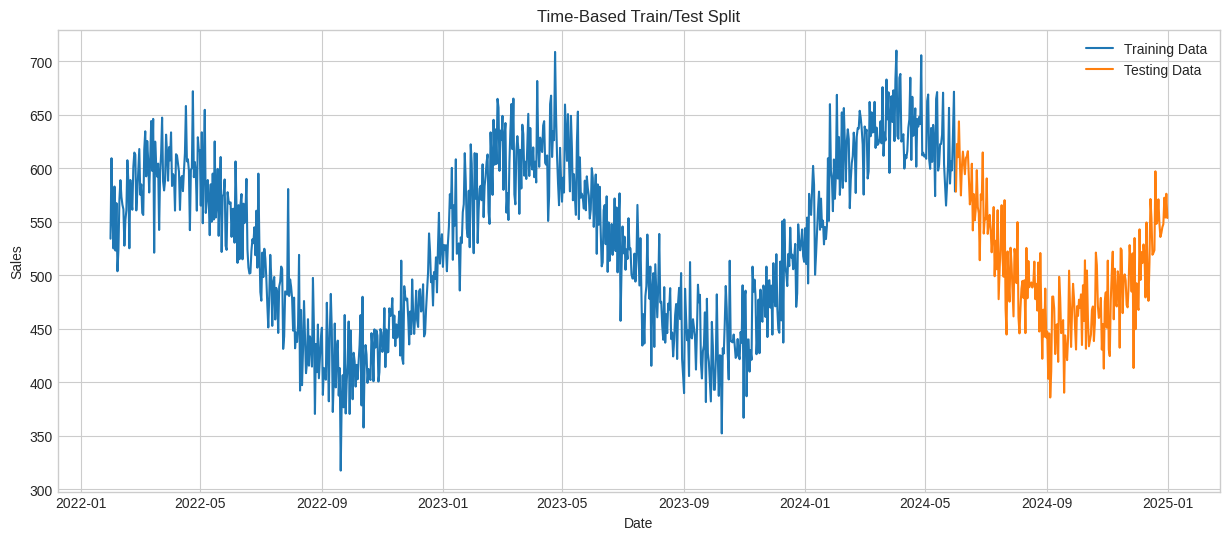

In [22]:
plt.figure(figsize=(15, 6))

plt.plot(
    df_model["Date"].iloc[:train_size],
    y_train,
    label="Training Data"
)

plt.plot(
    df_model["Date"].iloc[train_size:],
    y_test,
    label="Testing Data"
)

plt.title("Time-Based Train/Test Split")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

# 8. Model Training

## 8.1 Import Machine Learning Models and Evaluation Metrics

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

print("Models and evaluation metrics imported successfully!")

Models and evaluation metrics imported successfully!


## 8.2 Train Linear Regression Model

In [24]:
# Linear Regression Model

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


## 8.3 Train Random Forest Model:

In [25]:
# Random Forest Model

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


## 8.4 Train XGBoost Model

In [26]:
# XGBoost Model

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

print("XGBoost trained successfully!")

XGBoost trained successfully!


## 8.5 Compare Sample Predictions

In [27]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Linear Regression": lr_predictions,
    "Random Forest": rf_predictions,
    "XGBoost": xgb_predictions
})

comparison.head(10)

,Actual Sales,Linear Regression,Random Forest,XGBoost
0,578.20,617.996833,606.31150,605.464294
1,622.75,607.273641,627.74190,635.867188
2,610.41,604.355360,604.25105,580.907715
3,643.87,610.578916,602.68350,585.969482
4,604.49,617.115112,603.03625,573.868591
5,574.68,610.930428,604.01800,586.087646
6,601.65,605.575254,610.52600,623.153076
7,615.66,606.250400,615.20355,617.015625
8,605.46,611.451749,602.51955,574.150269
9,594.51,608.350083,600.09015,582.326477


# 9. Model Evaluation and Comparison

## 9.1 Define Evaluation Function

In [28]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2

## 9.2 Evaluate All Models

In [29]:
models_results = []

# Linear Regression
mae, rmse, r2 = evaluate_model(y_test, lr_predictions)

models_results.append({
    "Model": "Linear Regression",
    "MAE": mae,
    "RMSE": rmse,
    "R2 Score": r2
})

# Random Forest
mae, rmse, r2 = evaluate_model(y_test, rf_predictions)

models_results.append({
    "Model": "Random Forest",
    "MAE": mae,
    "RMSE": rmse,
    "R2 Score": r2
})

# XGBoost
mae, rmse, r2 = evaluate_model(y_test, xgb_predictions)

models_results.append({
    "Model": "XGBoost",
    "MAE": mae,
    "RMSE": rmse,
    "R2 Score": r2
})

results_df = pd.DataFrame(models_results)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,24.219020,30.347125,0.664219
1,Random Forest,29.029304,35.131873,0.549988
2,XGBoost,30.813748,37.142841,0.496996


## 9.3 Compare Model Performance

In [30]:
results_df.round(3)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,24.219,30.347,0.664
1,Random Forest,29.029,35.132,0.550
2,XGBoost,30.814,37.143,0.497


## 9.4 Select the Best Model

In [31]:
best_model_name = results_df.loc[
    results_df["RMSE"].idxmin(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Linear Regression


# 10. Future Sales Forecasting

## 10.1 Select the Best Model

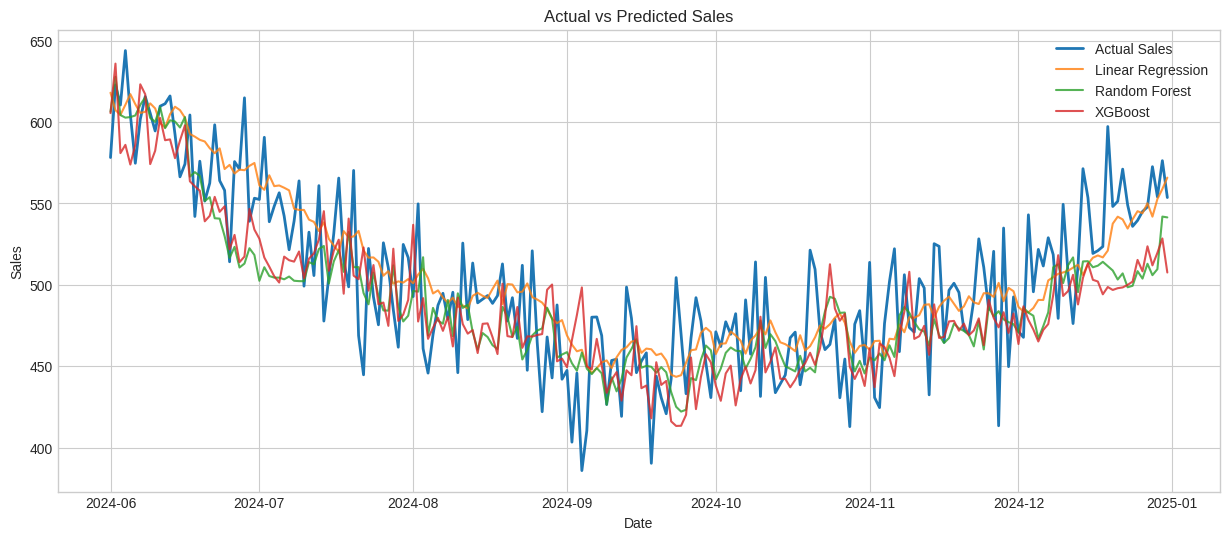

In [32]:
plt.figure(figsize=(15, 6))

plt.plot(
    test_dates,
    y_test.values,
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    test_dates,
    lr_predictions,
    label="Linear Regression",
    alpha=0.8
)

plt.plot(
    test_dates,
    rf_predictions,
    label="Random Forest",
    alpha=0.8
)

plt.plot(
    test_dates,
    xgb_predictions,
    label="XGBoost",
    alpha=0.8
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

## 10.2 Create Future Forecasting Function

In [33]:
model_mapping = {
    "Linear Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

best_model = model_mapping[best_model_name]

print(f"Selected Best Model: {best_model_name}")

Selected Best Model: Linear Regression


## 10.3 Generate 30-Day Sales Forecast

In [34]:
def forecast_future_sales(model, data, days=30):

    forecast_data = data[["Date", "Sales"]].copy()

    future_predictions = []

    for _ in range(days):

        # Next date
        next_date = forecast_data["Date"].max() + pd.Timedelta(days=1)

        # Date features
        year = next_date.year
        month = next_date.month
        day = next_date.day
        day_of_week = next_date.dayofweek
        week_of_year = next_date.isocalendar().week
        quarter = next_date.quarter

        # Historical sales
        sales_history = forecast_data["Sales"]

        # Lag features
        lag_1 = sales_history.iloc[-1]
        lag_7 = sales_history.iloc[-7]
        lag_30 = sales_history.iloc[-30]

        # Rolling averages
        rolling_mean_7 = sales_history.iloc[-7:].mean()
        rolling_mean_30 = sales_history.iloc[-30:].mean()

        # Feature DataFrame
        future_X = pd.DataFrame({
            "Year": [year],
            "Month": [month],
            "Day": [day],
            "DayOfWeek": [day_of_week],
            "WeekOfYear": [week_of_year],
            "Quarter": [quarter],
            "Lag_1": [lag_1],
            "Lag_7": [lag_7],
            "Lag_30": [lag_30],
            "Rolling_Mean_7": [rolling_mean_7],
            "Rolling_Mean_30": [rolling_mean_30]
        })

        # Prediction
        prediction = model.predict(future_X)[0]

        future_predictions.append({
            "Date": next_date,
            "Predicted_Sales": prediction
        })

        # Add prediction to history for next day's forecast
        forecast_data = pd.concat(
            [
                forecast_data,
                pd.DataFrame({
                    "Date": [next_date],
                    "Sales": [prediction]
                })
            ],
            ignore_index=True
        )

    return pd.DataFrame(future_predictions)

## 10.4 Forecast Summary

In [35]:
future_forecast = forecast_future_sales(
    best_model,
    df_model,
    days=30
)

future_forecast

,Date,Predicted_Sales
0,2025-01-01,565.567563
1,2025-01-02,563.771151
2,2025-01-03,571.021291
3,2025-01-04,572.561479
4,2025-01-05,575.366029
5,2025-01-06,570.497399
6,2025-01-07,572.660135
7,2025-01-08,579.411382
8,2025-01-09,576.913610
9,2025-01-10,583.185439


## 10.5 Visualize Future Sales Forecast

In [36]:
print("30-Day Sales Forecast Summary")
print("-" * 40)

print("Total Expected Sales:",
      round(future_forecast["Predicted_Sales"].sum(), 2))

print("Average Daily Sales:",
      round(future_forecast["Predicted_Sales"].mean(), 2))

print("Highest Predicted Sales:",
      round(future_forecast["Predicted_Sales"].max(), 2))

print("Lowest Predicted Sales:",
      round(future_forecast["Predicted_Sales"].min(), 2))

30-Day Sales Forecast Summary
----------------------------------------
Total Expected Sales: 17696.61
Average Daily Sales: 589.89
Highest Predicted Sales: 613.75
Lowest Predicted Sales: 563.77


# 11. Feature Importance Analysis

## 11.1 Calculate Feature Importance

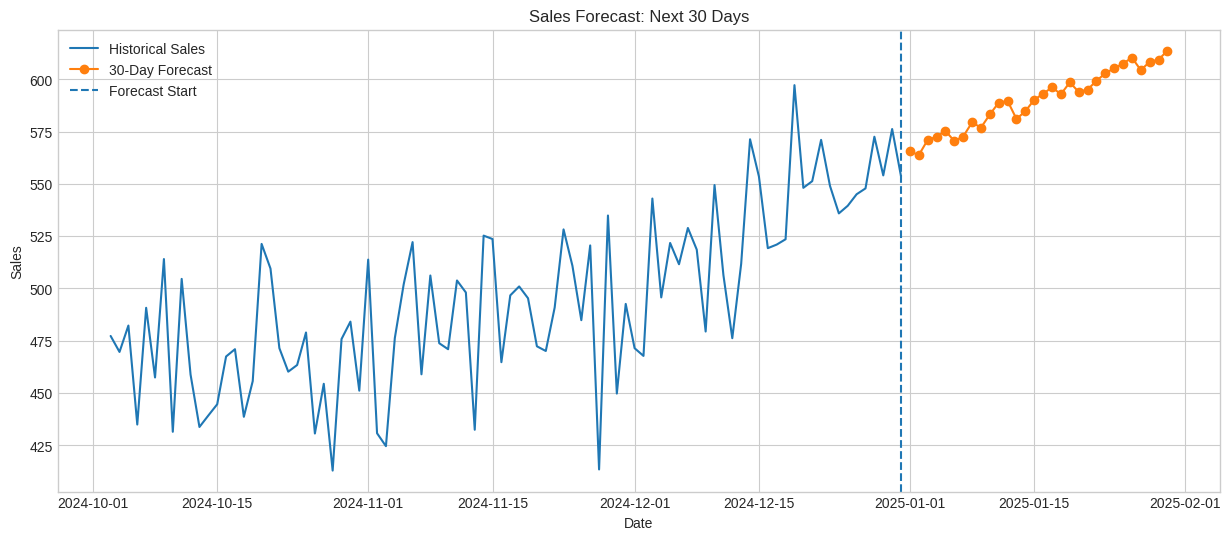

In [37]:
plt.figure(figsize=(15, 6))

# Last 90 days of actual sales
plt.plot(
    df_model["Date"].tail(90),
    df_model["Sales"].tail(90),
    label="Historical Sales"
)

# Next 30 days prediction
plt.plot(
    future_forecast["Date"],
    future_forecast["Predicted_Sales"],
    label="30-Day Forecast",
    marker="o"
)

plt.axvline(
    x=df_model["Date"].max(),
    linestyle="--",
    label="Forecast Start"
)

plt.title("Sales Forecast: Next 30 Days")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

## 11.2 Visualize Feature Importance

In [38]:
# Get feature importance based on best model

if best_model_name == "Linear Regression":
    importance = np.abs(best_model.coef_)

elif best_model_name == "Random Forest":
    importance = best_model.feature_importances_

elif best_model_name == "XGBoost":
    importance = best_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
5,Quarter,4.149289
0,Year,2.797357
1,Month,1.380398
3,DayOfWeek,0.937199
9,Rolling_Mean_7,0.733294
4,WeekOfYear,0.311181
10,Rolling_Mean_30,0.286250
2,Day,0.133316
8,Lag_30,0.086470
7,Lag_7,0.019336


# 11.3 Feature Importance Graph

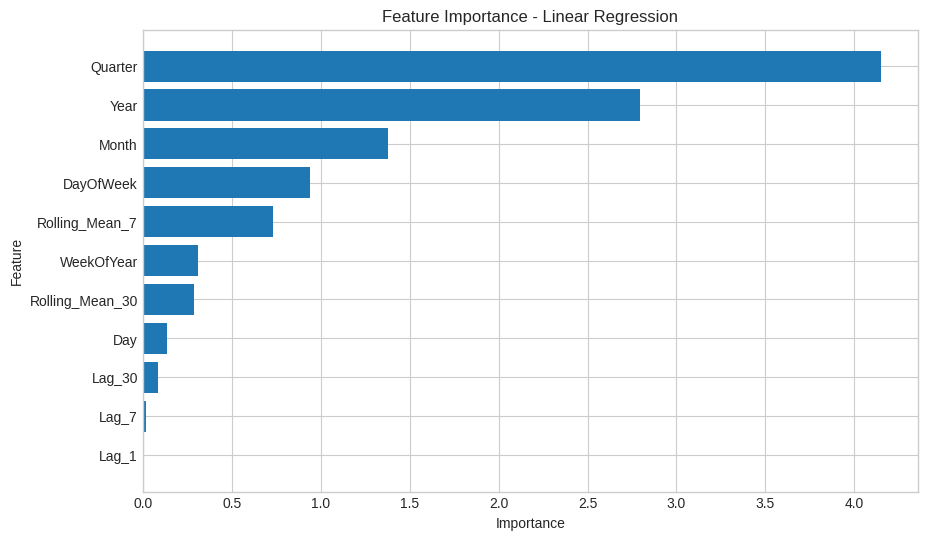

In [39]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Feature Importance - {best_model_name}")

plt.gca().invert_yaxis()

plt.show()

# 12. Business Insights

In [40]:
# Highest forecast day
highest_day = future_forecast.loc[
    future_forecast["Predicted_Sales"].idxmax()
]

# Lowest forecast day
lowest_day = future_forecast.loc[
    future_forecast["Predicted_Sales"].idxmin()
]

print("📊 BUSINESS INSIGHTS")
print("=" * 50)

print(f"Best Model: {best_model_name}")
print(f"Forecast Period: {future_forecast['Date'].min().date()} to {future_forecast['Date'].max().date()}")

print("\n💰 Expected 30-Day Sales:")
print(round(future_forecast["Predicted_Sales"].sum(), 2))

print("\n📈 Average Daily Sales:")
print(round(future_forecast["Predicted_Sales"].mean(), 2))

print("\n🔥 Highest Expected Sales:")
print(f"Date: {highest_day['Date'].date()}")
print(f"Sales: {highest_day['Predicted_Sales']:.2f}")

print("\n📉 Lowest Expected Sales:")
print(f"Date: {lowest_day['Date'].date()}")
print(f"Sales: {lowest_day['Predicted_Sales']:.2f}")

📊 BUSINESS INSIGHTS
Best Model: Linear Regression
Forecast Period: 2025-01-01 to 2025-01-30

💰 Expected 30-Day Sales:
17696.61

📈 Average Daily Sales:
589.89

🔥 Highest Expected Sales:
Date: 2025-01-30
Sales: 613.75

📉 Lowest Expected Sales:
Date: 2025-01-02
Sales: 563.77


# 13. Save Project Outputs

## 13.1 Save Best Model


In [41]:
import joblib

# Save the best model
joblib.dump(
    best_model,
    "best_sales_forecasting_model.pkl"
)

print("Best model saved successfully!")

Best model saved successfully!


## 13.2 Save Future Sales Forecast

In [42]:
future_forecast.to_csv(
    "future_sales_forecast.csv",
    index=False
)

print("Future forecast saved successfully!")

Future forecast saved successfully!


# 14. Conclusion

This project successfully developed a Machine Learning-based Sales Forecasting system to predict future sales using historical sales data.

The project involved data analysis, data cleaning, feature engineering, and time-series-based machine learning modeling. Multiple models, including Linear Regression, Random Forest, and XGBoost, were trained and evaluated using MAE, RMSE, and R² Score.

The best-performing model was selected based on its predictive performance and used to generate a 30-day future sales forecast. Lag features and rolling average features helped the models capture historical sales patterns and improve forecasting performance.

The final model provides valuable business insights, including expected future sales, average daily sales, and high- and low-demand periods. This forecasting approach can support better business planning, inventory management, and decision-making.

Overall, this project demonstrates an end-to-end Machine Learning workflow for time-series sales forecasting, from data preparation and model development to future prediction and business insights.

## **Project Status: Completed Successfully**